In this notebook, we clean the data by removing stationary segments, uneeded/unlabled data and we also label the parts where the robot is turning and it is not moving with a constant velocity.

**Input**: Labeled dataset from `data/labeled/`  
**Output**: Cleaned data set saved in `data/cleaned/`  


In [53]:
from pathlib import Path
import sys
import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io import load_run, save_labeled_run
from src.labels import plot_labeled_sensors

In [54]:
# Loading the labeled run
labeled_run_path = PROJECT_ROOT / "data" / "labeled" / "labeled_dataset.csv"

if not labeled_run_path.exists():
    raise FileNotFoundError(f"Labeled dataset not found: {labeled_run_path}\nPlease run 03_labelling.ipynb first.")

labeled_df = pd.read_csv(labeled_run_path)


print(f"Loaded labeled dataset: {labeled_run_path}")
print(f"Shape: {labeled_df.shape}")
print(f"Columns: {list(labeled_df.columns)}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")
print(f"\nRun IDs:")
for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")



/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_5586/1079418764.py:7: DtypeWarning: Columns (0: label) have mixed types. Specify dtype option on import or set low_memory=False.
  labeled_df = pd.read_csv(labeled_run_path)


Loaded labeled dataset: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/labeled/labeled_dataset.csv
Shape: (511450, 12)
Columns: ['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'label']
Unique run_ids: 2

Run IDs:
  - log_20260223_142511.490: 292115 samples
  - log_20260226_102148.990: 219335 samples


In [55]:
# Removing unlabeled samples
labeled_df = labeled_df.dropna(subset=['label'])
print(f"\nAfter removing unlabeled samples:")
print(f"Shape: {labeled_df.shape}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")
for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")



After removing unlabeled samples:
Shape: (59600, 12)
Unique run_ids: 2
  - log_20260223_142511.490: 41600 samples
  - log_20260226_102148.990: 18000 samples


In [56]:
# Adding derived odometry columns before low-velocity filtering
W = 0.5  # wheel distance in meters (set this, e.g., 0.35)

if W is None or W <= 0:
    raise ValueError("Please set W to the wheel distance in meters (W > 0) before running this cell.")

labeled_df['net_speed'] = (labeled_df['v1'] + labeled_df['v2']) / 2.0
labeled_df['yaw_rate'] = (labeled_df['v1'] - labeled_df['v2']) / W

print("Added columns: net_speed, yaw_rate")
print(labeled_df[['v1', 'v2', 'net_speed', 'yaw_rate']].head())

Added columns: net_speed, yaw_rate
             v1        v2  net_speed  yaw_rate
31019  0.406051  0.573000   0.489526 -0.333897
31020  0.384789  0.570368   0.477579 -0.371158
31021  0.385667  0.585974   0.485821 -0.400615
31022  0.391059  0.599647   0.495353 -0.417176
31023  0.402507  0.593779   0.498143 -0.382545


In [43]:
# Removing low-velocity segments (the points where the robot is probably turning or stopping, which can be ambiguous for labeling)
low_velocity_mask = (labeled_df['v1'] < 0.3) | (labeled_df['v2'] < 0.3)

n_low_velocity = int(low_velocity_mask.sum())
n_total_before = len(labeled_df)

labeled_df = labeled_df.loc[~low_velocity_mask].copy()

print(f"\nRemoved low-velocity samples (v1 < 0.3 or v2 < 0.3): {n_low_velocity}")
print(f"Samples before: {n_total_before}")
print(f"Samples after: {len(labeled_df)}")
print(f"Shape: {labeled_df.shape}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")
for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")


Removed low-velocity samples (v1 < 0.3 or v2 < 0.3): 2701
Samples before: 59600
Samples after: 56899
Shape: (56899, 12)
Unique run_ids: 2
  - log_20260223_142511.490: 38915 samples
  - log_20260226_102148.990: 17984 samples



Plotting labeled sensors for log_20260223_142511.490...


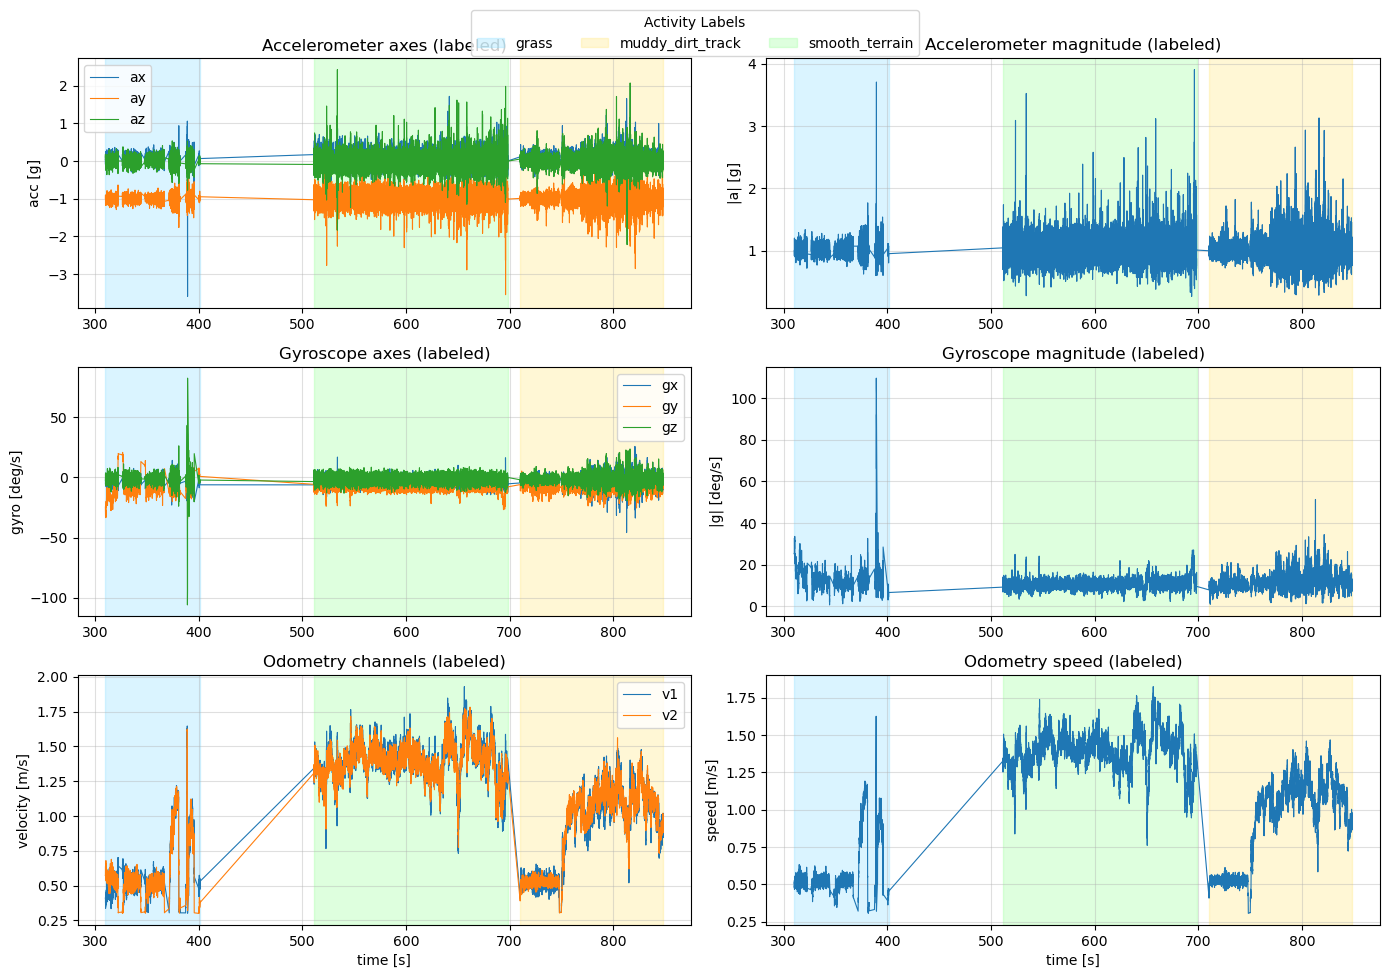


Plotting labeled sensors for log_20260226_102148.990...


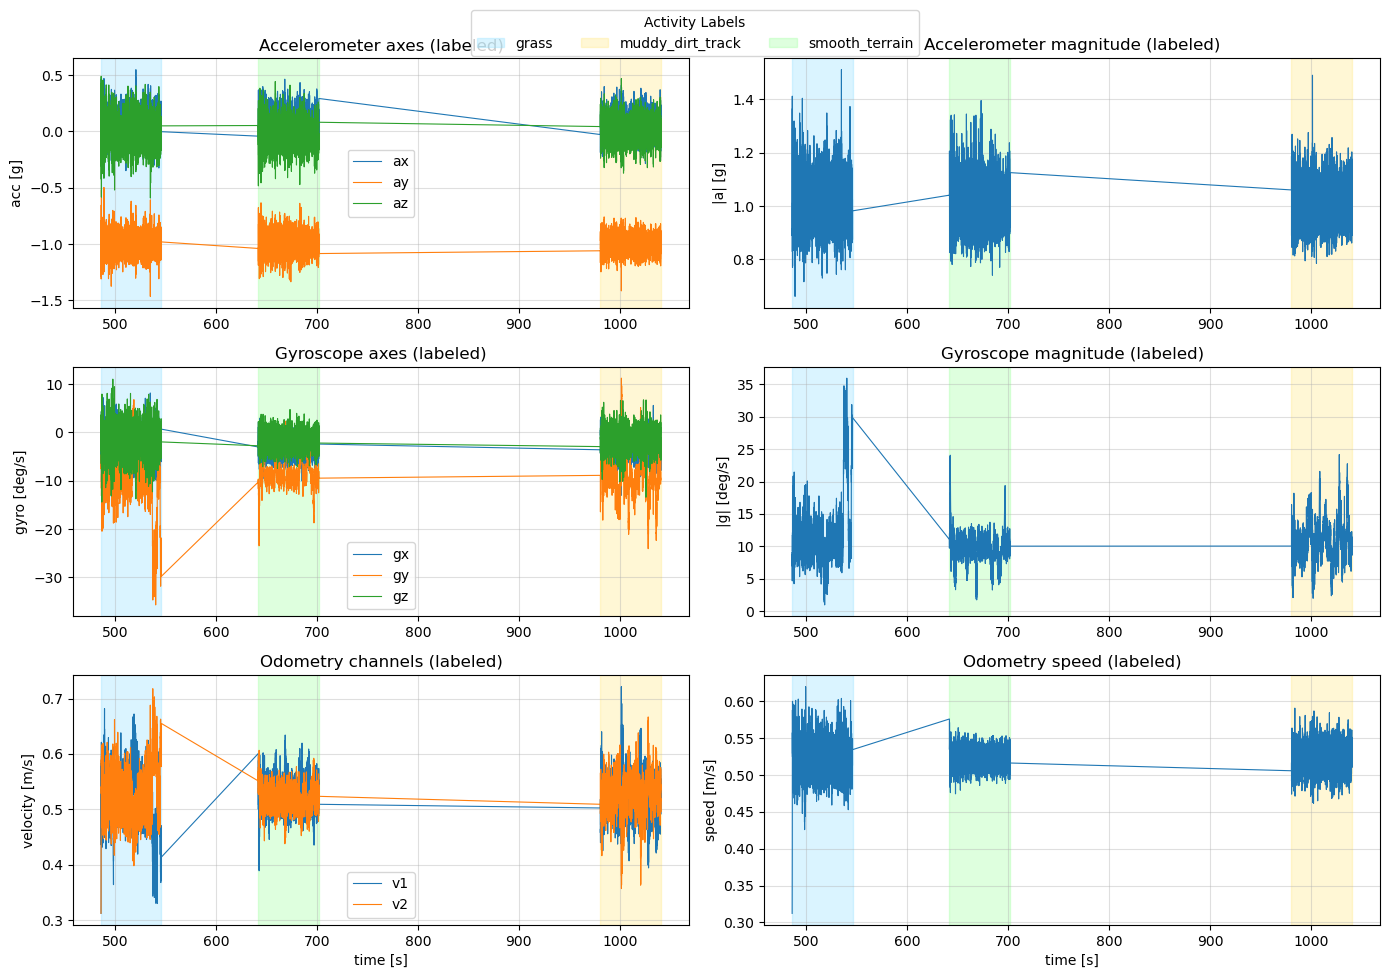

In [44]:
# Plotting after removing unlabeled samples (per run) not necessary to run every time but as a check
if labeled_df.empty:
    print("No labeled samples available to plot.")
else:
    for run_id in sorted(labeled_df['run_id'].unique()):
        run_df = labeled_df[labeled_df['run_id'] == run_id].copy()

        acc_labeled = run_df[['t', 't_rel', 'ax', 'ay', 'az', 'label']].copy()
        gyro_labeled = run_df[['t', 't_rel', 'gx', 'gy', 'gz', 'label']].copy()
        odo_labeled = run_df[['t', 't_rel', 'v1', 'v2', 'label']].copy()

        print(f"\nPlotting labeled sensors for {run_id}...")
        _ = plot_labeled_sensors(
            acc=acc_labeled,
            gyro=gyro_labeled,
            odo=odo_labeled,
            tcol='t_rel',
            show=True
        )